# Comparing min module size in WGCNA 
I've run WGCNA for phase 1 samples with different minimum module sizes -> [100 genes](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase1_v_phase1/wgcna/newRef_wgcna_p1.ipynb) and [50 genes](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase1_v_phase1/wgcna/smallerModules_wgcna_p1.ipynb) minimum

I'm interested to see how these modules get split up with smaller min. module sizes

## 0. load libraries

In [5]:
library(tidyverse)
library(UpSetR) # for upset plots

## 1. read csvs

### 100 min module

In [22]:
min100 <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/wgcna/outputs/p1.wgcna_GeneInfo.csv') %>%
select(Gene, module_df1 = ModuleColor) 

dim(min100)
head(min100)

[1] 7634    2

,Gene,module_df1
,<chr>,<chr>
1,LOC111099029,blue
2,LOC111099037,black
3,LOC111099039,blue
4,LOC111099041,red
5,LOC111099050,green
6,LOC111099053,blue


### 50 min module

In [24]:
min50 <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/wgcna/outputs/p1.smallModule_GeneInfo.csv') %>%
select(Gene, module_df2 = ModuleColor) 

dim(min50)
head(min50)

[1] 7634    2

,Gene,module_df2
,<chr>,<chr>
1,LOC111099029,brown
2,LOC111099037,blue
3,LOC111099039,lightcyan
4,LOC111099041,black
5,LOC111099050,black
6,LOC111099053,brown


keep only genes present in both data sets (which should be the same genes?)

In [25]:
matched <- inner_join(min100, min50, by = "Gene")

head(matched)
dim(matched)

,Gene,module_df1,module_df2
,<chr>,<chr>,<chr>
1,LOC111099029,blue,brown
2,LOC111099037,black,blue
3,LOC111099039,blue,lightcyan
4,LOC111099041,red,black
5,LOC111099050,green,black
6,LOC111099053,blue,brown


[1] 7634    3

count genes for each module combination

In [26]:
module_counts <- matched %>%
  count(module_df1, module_df2)

head(module_counts)

,module_df1,module_df2,n
,<chr>,<chr>,<int>
1,black,blue,38
2,black,lightcyan,59
3,black,red,430
4,black,tan,1
5,blue,blue,5
6,blue,brown,1093


## 2. Plot

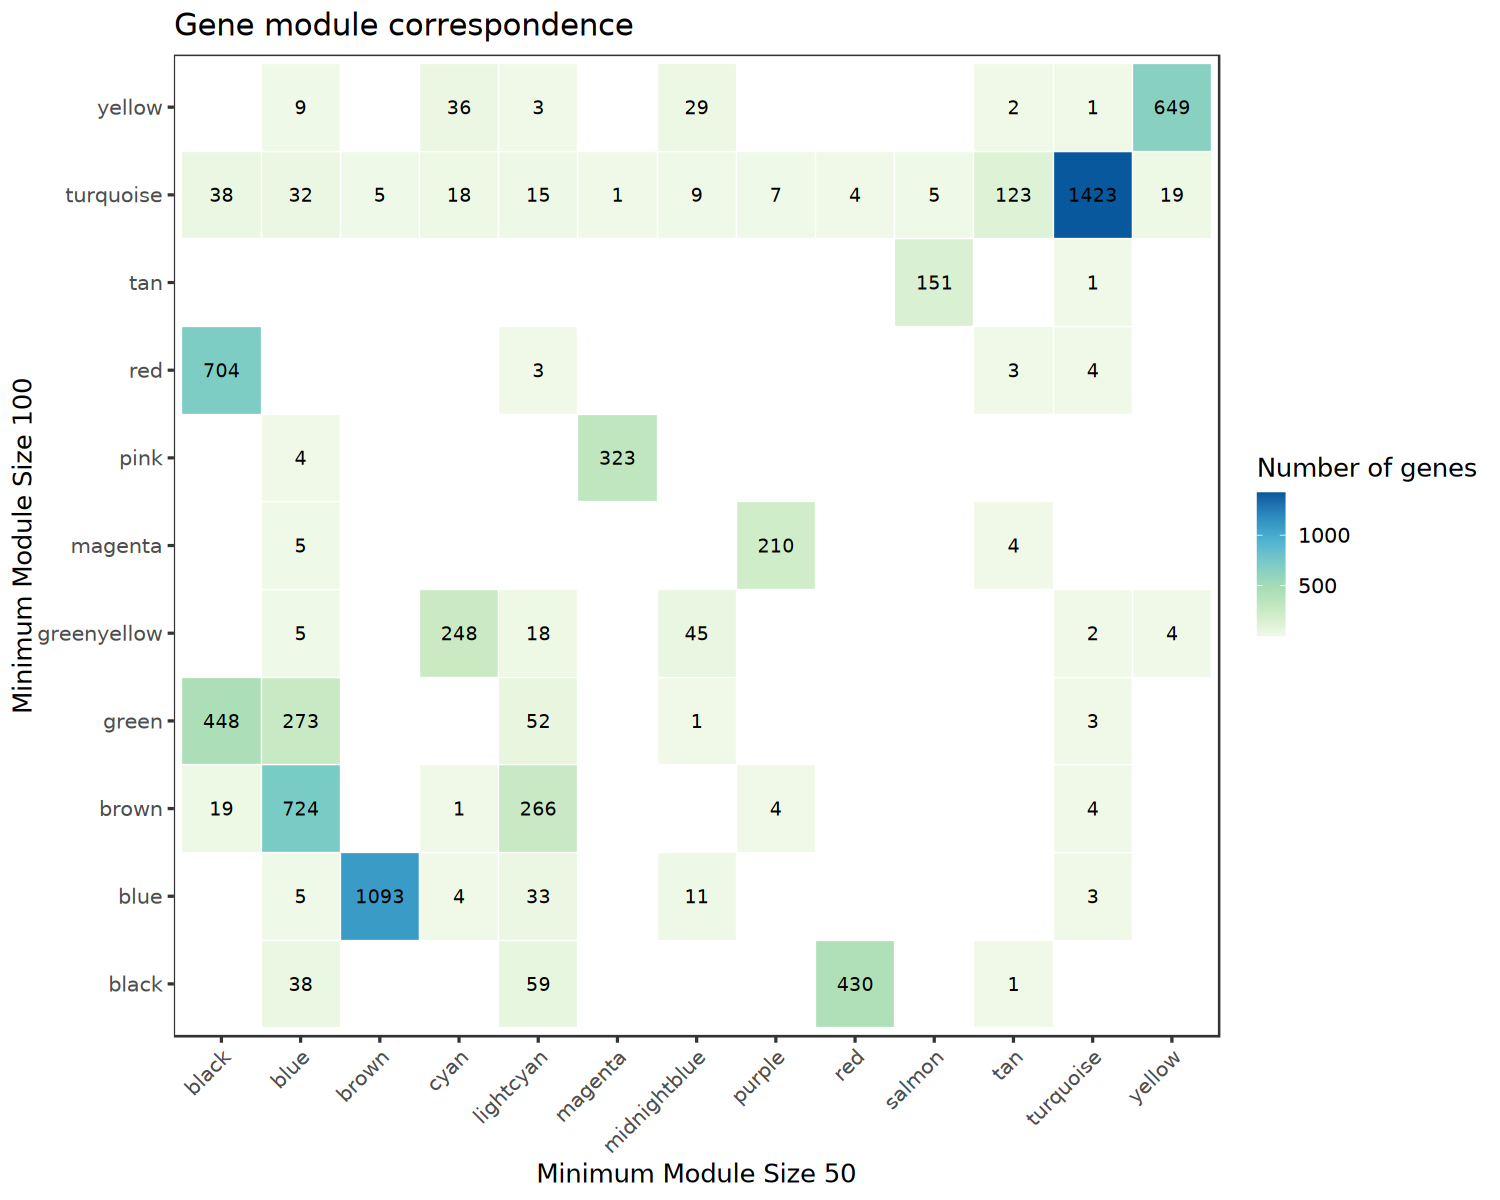

In [47]:
options(repr.plot.width = 12.5, repr.plot.height = 10)

# Plot correspondence
ggplot(module_counts,
       aes(x = module_df2,
           y = module_df1,
           fill = n)) +
  geom_tile(color = "white") +
  geom_text(aes(label = n), size = 4, color = 'black') +
   scale_fill_distiller(
  palette = "GnBu",
  direction = 1
) +
  labs(
    x = "Minimum Module Size 50",
    y = "Minimum Module Size 100",
    fill = "Number of genes",
    title = "Gene module correspondence"
  ) +
  theme_bw(base_size = 15) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.grid = element_blank()
  )

change to percentages

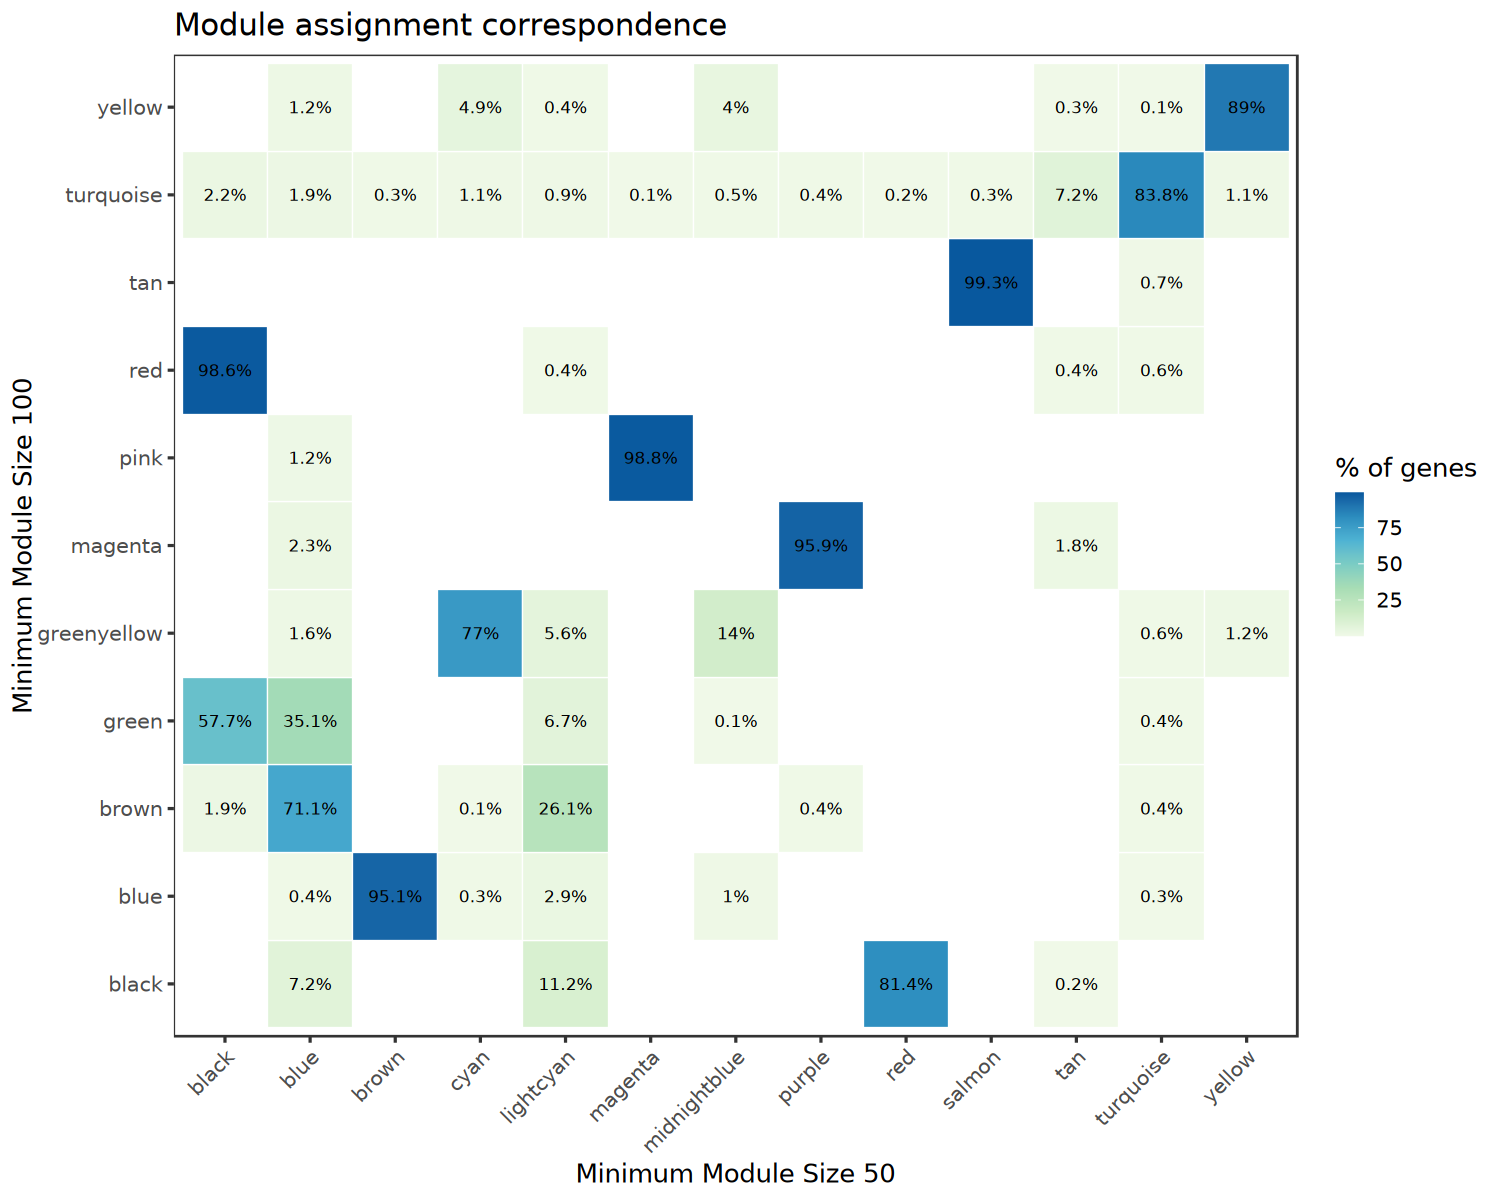

In [45]:
module_pct <- matched %>%
  count(module_df1, module_df2) %>%
  group_by(module_df1) %>%
  mutate(percent = 100 * n / sum(n)) %>%
  ungroup()

ggplot(module_pct,
       aes(x = module_df2,
           y = module_df1,
           fill = percent)) +
  geom_tile(color = "white") +
  geom_text(aes(label = paste0(round(percent, 1), "%")),
            size = 3.5,
           color = 'black') +
 scale_fill_distiller(
  palette = "GnBu",
  direction = 1
) +
  labs(
    x = "Minimum Module Size 50",
    y = "Minimum Module Size 100",
    fill = "% of genes",
    title = "Module assignment correspondence"
  ) +
  theme_bw(base_size = 15) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.grid = element_blank()
  )


the green, brown, and black modules got broken down with a smaller minimum module size - everything else remained more or less the same between the two module sizes 

when the min. module size is set to 100, the significantly correlated modules were red, blue, and black
- genes in the red module (min100) remain together in the black module (98.6%) for min50
- genes in the blue module (min100) remain mostly together in the brown module (95.1%) for min50
- genes in the black module (min100) remain mostly together in the red module (81.4%) for min50, but also have some that are assigned to the blue (7.2%) and lightcyan (11.2%) module too
>the percentrages are based on the number of genes in the min100 module that match to the min50 modules - also there are more modules in the min50 modules, so there's not a 1:1 match

but now I'm wondering if I only saw those modules show up as signficantly correlated, or if there were new/more modules that are now signficantly correlated with smaller min. module sizes 


**looking at the min50 heat map [here](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase1_v_phase1/wgcna/smallerModules_wgcna_p1.ipynb):**
- see 5 total modules with significant correlations
- red = neg. phase 1 temp, pos. control
    - corresponds to black module in min100 (neg. phase 1 temp; so now have a new correlation with a smaller module min)
- midnightblue = pos. shell growth
    - mostly corresponds to greenyellow module in min100 (which was a non-signif module)
- brown = pos. shell growth, pos. warm
    - mostly corresponds to blue module in min100 (same correlations)
- blue = neg. warm
    - mostly corresponds to brown module (non-signif) but also green module (also non-signif) in min100 (so this is a new correlated gene network!)
- black = neg. shell growth
    - mostly corresponds to red module (neg. tissue growth) but also green module (non-signif) in min100 (so went from being correlated to tissue growth to now being correlated with shell growth ... how??)

so I was able to identify a new correlated network, but mostly everything else stayed the same (probably just removed some noise)
